# Interactive Stock Market Analysis Dashboard

## Problem Statement
This dashboard will analyze stock market data to provide beginner investors with an understanding of market trends, volatility, and investment indicators.

## Target Audience
- Beginner investors
- Students of finance

#Import Libraries

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

#Data Collection

In [3]:
# Download Tesla stock data
data = yf.download("TSLA", start="2020-01-01", end="2025-01-01")

data.head()

/tmp/ipykernel_13687/627545722.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("TSLA", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


#Data Cleaning

In [4]:
# Remove missing values
data = data.dropna()

# Check structure
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1258 non-null   float64
 1   (High, TSLA)    1258 non-null   float64
 2   (Low, TSLA)     1258 non-null   float64
 3   (Open, TSLA)    1258 non-null   float64
 4   (Volume, TSLA)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


#Data Preparation

In [5]:
# Keep only Close price
data = data[['Close']].copy()

# Create new features
data['MA50'] = data['Close'].rolling(50).mean()
data['MA200'] = data['Close'].rolling(200).mean()
data['Returns'] = data['Close'].pct_change()

data.head()

Price,Close,MA50,MA200,Returns
Ticker,TSLA,,,
Date,,,,
2020-01-02,28.684000,NaN,NaN,NaN
2020-01-03,29.534000,NaN,NaN,0.029633
2020-01-06,30.102667,NaN,NaN,0.019255
2020-01-07,31.270666,NaN,NaN,0.038801
2020-01-08,32.809334,NaN,NaN,0.049205


#Visualization: Price Trend

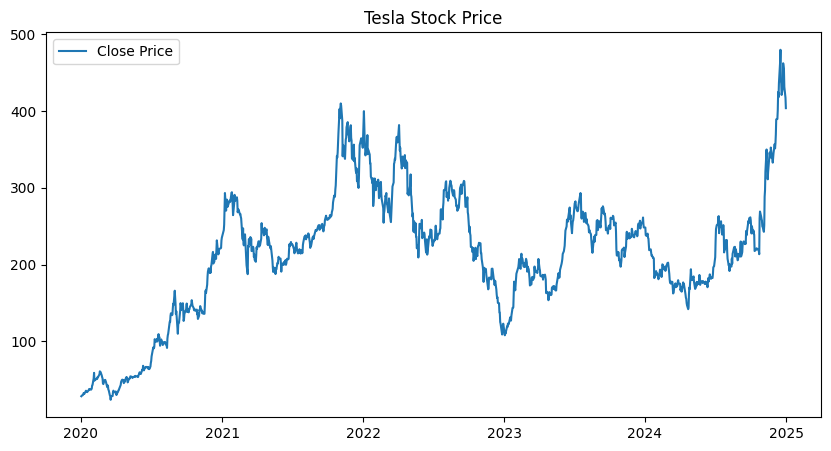

In [6]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close Price')
plt.title("Tesla Stock Price")
plt.legend()
plt.show()

#Visualization: Moving Averages

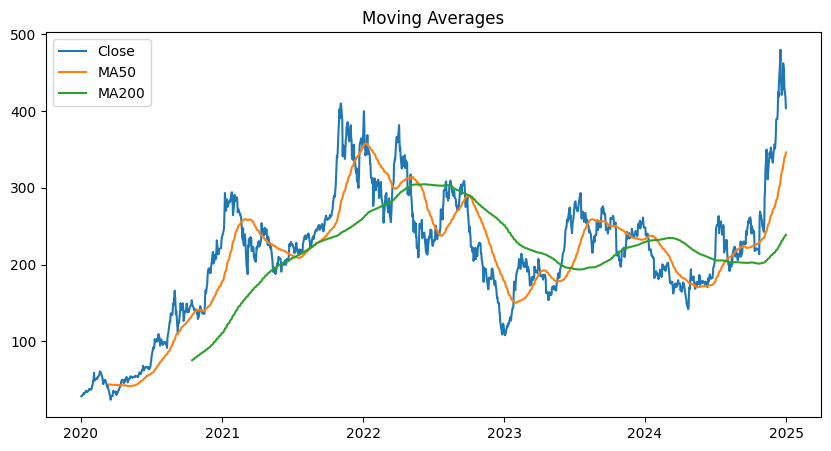

In [7]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close')
plt.plot(data['MA50'], label='MA50')
plt.plot(data['MA200'], label='MA200')
plt.title("Moving Averages")
plt.legend()
plt.show()

#Visualization: Returns

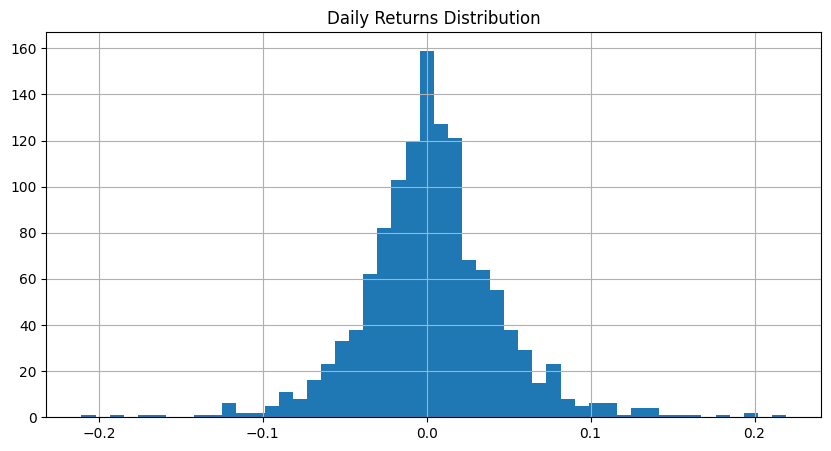

In [8]:
plt.figure(figsize=(10,5))
data['Returns'].hist(bins=50)
plt.title("Daily Returns Distribution")
plt.show()

#Key Metrics

In [9]:
latest_price = data['Close'].iloc[-1]
avg_price = data['Close'].mean()
volatility = data['Returns'].std()

print("Latest Price:", latest_price)
print("Average Price:", avg_price)
print("Volatility:", volatility)

Latest Price: Ticker
TSLA    403.839996
Name: 2024-12-31 00:00:00, dtype: float64
Average Price: Ticker
TSLA    213.430922
dtype: float64
Volatility: 0.04232038497495289


#Investment Signal

In [10]:
if data['MA50'].iloc[-1] > data['MA200'].iloc[-1]:
    print("Bullish Trend (Buy Signal)")
else:
    print("Bearish Trend (Sell Signal)")

Bullish Trend (Buy Signal)


## Observations

- There is high volatility in Tesla stock, implying higher risk.
- Moving averages give long-term insights.
- The stock keeps alternating between bullish and bearish trends.
- This can help investors make easy choices.

## Data Source

- Source: Yahoo Finance
- Accessed: April 2026
- Data collected using Python yfinance library